### Data Ingestion

In [2]:
import sklearn
sklearn.show_versions()


System:
    python: 3.12.1 (main, May  6 2025, 20:30:25) [GCC 9.4.0]
executable: /home/codespace/.cache/pypoetry/virtualenvs/practice-fNXuwuO0-py3.12/bin/python
   machine: Linux-6.8.0-1044-azure-x86_64-with-glibc2.31

Python dependencies:
      sklearn: 1.8.0
          pip: 26.0.1
   setuptools: None
        numpy: 2.4.3
        scipy: 1.17.1
       Cython: None
       pandas: 2.3.0
   matplotlib: 3.10.8
       joblib: 1.5.3
threadpoolctl: 3.6.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: openblas
    num_threads: 4
         prefix: libscipy_openblas
       filepath: /home/codespace/.cache/pypoetry/virtualenvs/practice-fNXuwuO0-py3.12/lib/python3.12/site-packages/numpy.libs/libscipy_openblas64_-ff84a88b.so
        version: 0.3.31.dev
threading_layer: pthreads
   architecture: Haswell

       user_api: blas
   internal_api: openblas
    num_threads: 4
         prefix: libscipy_openblas
       filepath: /home/codespace/.cache/pypoetry/virtualenv

In [8]:
import os
import pandas as pd
from sklearn.datasets import fetch_openml

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

data_dir = os.path.join(os.getcwd(), "data")
os.makedirs(data_dir, exist_ok=True)

raw_dir = os.path.join(data_dir, "raw")
os.makedirs(raw_dir, exist_ok=True)

train_dir = os.path.join(data_dir, "train")
os.makedirs(train_dir, exist_ok=True)

test_dir = os.path.join(data_dir, "test")
os.makedirs(test_dir, exist_ok=True)


X, y = fetch_openml("credit-g",
             return_X_y=True,
             as_frame=True,
             version=1)
df = pd.concat([X,y], axis=1)

file_name = "credit_score.csv"
file_path = os.path.join(raw_dir, file_name)

if not os.path.exists(file_path):
    print(f"Saving credit score file to: {file_path}")
    df.to_csv(file_path, index=False)

### EDA

In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)

file_path = "/workspaces/ml_practice/data/raw/credit_score.csv"

df = pd.read_csv(file_path)

In [ ]:
train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])[0]

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
29,<0,60,delayed previously,business,6836,<100,>=7,3,male single,none,...,no known property,63,none,own,2,skilled,1,yes,yes,bad
535,>=200,21,critical/other existing credit,education,2319,<100,<1,2,male div/sep,none,...,car,33,none,rent,1,skilled,1,none,yes,bad
695,no checking,6,existing paid,used car,1236,500<=X<1000,1<=X<4,2,male single,none,...,life insurance,50,none,rent,1,skilled,1,none,yes,good
557,no checking,21,no credits/all paid,new car,5003,no known savings,1<=X<4,1,female div/dep/mar,none,...,life insurance,29,bank,own,2,skilled,1,yes,yes,bad
836,no checking,12,existing paid,radio/tv,886,no known savings,1<=X<4,4,female div/dep/mar,none,...,car,21,none,own,1,skilled,1,none,yes,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,no checking,18,all paid,new car,6458,<100,>=7,2,male single,none,...,no known property,39,bank,own,2,high qualif/self emp/mgmt,2,yes,yes,bad
270,no checking,18,existing paid,new car,2662,no known savings,4<=X<7,4,male single,none,...,life insurance,32,none,own,1,skilled,1,none,no,good
860,no checking,24,critical/other existing credit,used car,5804,>=1000,1<=X<4,4,male single,none,...,real estate,27,none,own,2,skilled,1,none,yes,good
435,0<=X<200,12,existing paid,radio/tv,1484,no known savings,1<=X<4,2,male mar/wid,none,...,real estate,25,none,own,1,skilled,1,yes,yes,bad


array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'credit_amount'}>],
       [<Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

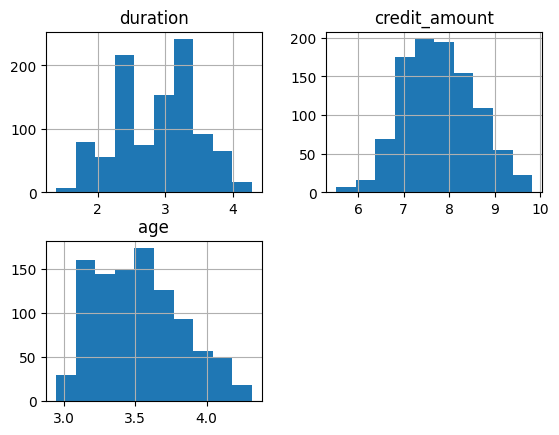

In [34]:
np.log(df[["duration", "credit_amount", "age"]]).hist()

In [15]:
from sklearn.preprocessing import OneHotEncoder
import time

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
ohe_sklearn = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

start = time.perf_counter()
# Method 1: Using sklearn's OneHotEncoder
df_ohe_sklearn = ohe_sklearn.fit_transform(df[categorical_cols])

mid = time.perf_counter()

# Method 2: Using pandas get_dummies
df_ohe_pandas = pd.get_dummies(df[categorical_cols], dtype=int)

end = time.perf_counter()

print(mid-start)
print(end-mid)

0.01241608800000904
0.007322177000105512


In [17]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
ohe_sklearn = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

start = time.perf_counter()
# Method 1: Using sklearn's OneHotEncoder
df_ohe_sklearn = ohe_sklearn.fit_transform(df[categorical_cols])

In [28]:
df.columns

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')

In [90]:
import time

series = df["class"]
encoder = LabelEncoder()

start = time.time()

series_enc = encoder.fit_transform(series)


mid = time.time()

series.replace({
    "bad":1,
    "good":0
})

end = time.time()

print(mid - start)
print(end - mid)

0.000568389892578125
0.0012440681457519531


In [144]:
df["credit_amount"].to_numpy().astype(np.int16, casting="same_kind")

array([ 1169,  5951,  2096,  7882,  4870,  9055,  2835,  6948,  3059,
        5234,  1295,  4308,  1567,  1199,  1403,  1282,  2424,  8072,
       12579,  3430,  2134,  2647,  2241,  1804,  2069,  1374,   426,
         409,  2415,  6836,  1913,  4020,  5866,  1264,  1474,  4746,
        6110,  2100,  1225,   458,  2333,  1158,  6204,  6187,  6143,
        1393,  2299,  1352,  7228,  2073,  2333,  5965,  1262,  3378,
        2225,   783,  6468,  9566,  1961,  6229,  1391,  1537,  1953,
       14421,  3181,  5190,  2171,  1007,  1819,  2394,  8133,   730,
        1164,  5954,  1977,  1526,  3965,  4771,  9436,  3832,  5943,
        1213,  1568,  1755,  2315,  1412,  1295, 12612,  2249,  1108,
         618,  1409,   797,  3617,  1318, 15945,  2012,  2622,  2337,
        7057,  1469,  2323,   932,  1919,  2445, 11938,  6458,  6078,
        7721,  1410,  1449,   392,  6260,  7855,  1680,  3578,  7174,
        2132,  4281,  2366,  1835,  3868,  1768,   781,  1924,  2121,
         701,   639,

In [133]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder


def get_preprocessor() -> ColumnTransformer:
    categorical_cols = ['checking_status',
                        'credit_history',
                        'purpose',
                        'savings_status',
                        'employment',
                        'personal_status',
                        'other_parties',
                        'property_magnitude',
                        'other_payment_plans',
                        'housing',
                        'job',
                        'own_telephone',
                        'foreign_worker']

    numeric_cols = ['duration',
                    'credit_amount',
                    'installment_commitment',
                    'residence_since',
                    'age',
                    'existing_credits',
                    'num_dependents']

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols),
            ("num", StandardScaler(), numeric_cols)
        ],
        verbose=True
    )

    return preprocessor

def get_train_test_data(preprocessor: ColumnTransformer,
                        df: pd.DataFrame,
                        label_col: str) -> None:
    X = df.drop(columns=[label_col], axis=1)
    y = df[label_col]

    encoder = LabelEncoder()
    y_enc = encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

    X_train = preprocessor.fit_transform(X_train)
    X_test = preprocessor.transform(X_test)

    return X_train, X_test, y_train, y_test

### Data Quality

In [ ]:
import great_expectations as gx
import great_expectations.expectations as gxe
import os

In [10]:
project_root_dir = "./gx_practice"
if os.path.basename(os.getcwd()) == "notebooks":
    project_root_dir = "../gx_practice"

context = gx.get_context(mode="file", project_root_dir=project_root_dir)

In [11]:
context

{
  "checkpoint_store_name": "checkpoint_store",
  "config_variables_file_path": "uncommitted/config_variables.yml",
  "config_version": 4.0,
  "data_context_id": "9534c519-c560-44b3-8a6a-8c250192ad7c",
  "data_docs_sites": {
    "local_site": {
      "class_name": "SiteBuilder",
      "show_how_to_buttons": true,
      "store_backend": {
        "class_name": "TupleFilesystemStoreBackend",
        "base_directory": "uncommitted/data_docs/local_site/"
      },
      "site_index_builder": {
        "class_name": "DefaultSiteIndexBuilder"
      }
    }
  },
  "expectations_store_name": "expectations_store",
  "fluent_datasources": {},
  "plugins_directory": "plugins/",
  "stores": {
    "expectations_store": {
      "class_name": "ExpectationsStore",
      "store_backend": {
        "class_name": "TupleFilesystemStoreBackend",
        "base_directory": "expectations/"
      }
    },
    "validation_results_store": {
      "class_name": "ValidationResultsStore",
      "store_backend": {
 